# FASE 4 — Modelo de ejecución realista

En esta fase construiremos un modelo básico de ejecución utilizando
directamente los precios Bid y Ask de los ticks de EUR/USD.

El objetivo es abandonar la simplificación de ejecutar todas las
operaciones a un único precio.

Reglas fundamentales:

- Una compra (BUY) se ejecuta al Ask.
- El cierre de una compra se ejecuta al Bid.
- Una venta (SELL) se ejecuta al Bid.
- El cierre de una venta se ejecuta al Ask.

También incorporaremos un filtro de spread para decidir si las
condiciones de entrada son aceptables.

En esta fase todavía NO modelaremos:

- Slippage.
- Latencia.
- Comisiones.
- Swap.

Estos elementos se incorporarán posteriormente.

## 1. Configuración del entorno

Utilizaremos el archivo de ticks procesado creado en la Fase 3.

Este archivo contiene los ticks originales después de eliminar
únicamente los duplicados exactos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------

DATA_PROCESSED = Path("../data/processed")

SNAPSHOT_DATE = "20260908"

TICKS_FILE = (
    DATA_PROCESSED
    / f"eurusd_ticks_clean_{SNAPSHOT_DATE}.parquet"
)


# EUR/USD con cotización de 5 decimales
POINT = 0.00001

# 1 pip = 10 puntos
POINTS_PER_PIP = 10


print("Archivo de ticks:")
print(TICKS_FILE.resolve())

print("\nPOINT:")
print(POINT)

print("\nPuntos por pip:")
print(POINTS_PER_PIP)

Archivo de ticks:
C:\ALL\TECNICO\TRADING\CURSOS\TUTORIAS\PROYECTO2\mt5_microstructure_lab\data\processed\eurusd_ticks_clean_20260908.parquet

POINT:
1e-05

Puntos por pip:
10


## 2. Cargar los ticks procesados

Cargamos la base limpia generada en la Fase 3.

Mantendremos el orden cronológico original de los ticks.

In [2]:
if not TICKS_FILE.exists():
    raise FileNotFoundError(
        "No se encuentra el archivo procesado.\n"
        "Debe ejecutarse primero la Fase 3.\n\n"
        f"Archivo esperado:\n{TICKS_FILE.resolve()}"
    )


ticks = pd.read_parquet(
    TICKS_FILE
)

ticks["time"] = pd.to_datetime(
    ticks["time"],
    utc=True
)

ticks = (
    ticks
    .reset_index(drop=True)
)


print("Número de ticks:", len(ticks))

print(
    "Primer tick:",
    ticks["time"].min()
)

print(
    "Último tick:",
    ticks["time"].max()
)

print(
    "Orden cronológico:",
    ticks["time"].is_monotonic_increasing
)

Número de ticks: 1064157
Primer tick: 2026-09-01 00:17:05.574000+00:00
Último tick: 2026-09-08 00:16:56.458000+00:00
Orden cronológico: True


## 3. Verificar las variables necesarias

El modelo de ejecución necesita como mínimo:

- time
- bid
- ask
- spread_price
- spread_points

Comprobaremos que todas están disponibles.

Este detalle es muy importante por lo que encontramos en la Fase 2.

In [3]:
required_columns = [
    "time",
    "bid",
    "ask",
    "spread_price",
    "spread_points"
]


missing_columns = [
    column
    for column in required_columns
    if column not in ticks.columns
]


if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {missing_columns}"
    )


print(
    "Todas las columnas necesarias están disponibles."
)

Todas las columnas necesarias están disponibles.


## 4. Preparar la base para el modelo de ejecución

Crearemos:

- `tick_id`: identificador único de cada registro.
- `mid_price`: punto medio entre Bid y Ask.

Utilizaremos `tick_id` porque en nuestros datos pueden existir varios
ticks diferentes con exactamente el mismo timestamp.

Por tanto, el timestamp por sí solo no identifica necesariamente un
único tick.

Este detalle es muy importante por lo que encontramos en la Fase 2.

In [4]:
ticks_exec = (
    ticks
    .copy()
)


ticks_exec["tick_id"] = np.arange(
    len(ticks_exec)
)


ticks_exec["mid_price"] = (
    ticks_exec["bid"]
    +
    ticks_exec["ask"]
) / 2


display(
    ticks_exec[
        [
            "tick_id",
            "time",
            "bid",
            "ask",
            "mid_price",
            "spread_points"
        ]
    ].head(10)
)

,tick_id,time,bid,ask,mid_price,spread_points
0,0,2026-09-01 00:17:05.574000+00:00,1.16164,1.16173,1.161685,9.0
1,1,2026-09-01 00:17:05.775000+00:00,1.16164,1.16172,1.161680,8.0
2,2,2026-09-01 00:17:06.175000+00:00,1.16164,1.16173,1.161685,9.0
3,3,2026-09-01 00:17:06.276000+00:00,1.16164,1.16172,1.161680,8.0
4,4,2026-09-01 00:17:06.527000+00:00,1.16164,1.16173,1.161685,9.0
5,5,2026-09-01 00:17:06.576000+00:00,1.16164,1.16172,1.161680,8.0
6,6,2026-09-01 00:17:49.295000+00:00,1.16164,1.16174,1.161690,10.0
7,7,2026-09-01 00:17:49.328000+00:00,1.16166,1.16173,1.161695,7.0
8,8,2026-09-01 00:17:49.420000+00:00,1.16168,1.16173,1.161705,5.0
9,9,2026-09-01 00:17:51.269000+00:00,1.16168,1.16174,1.161710,6.0


## 5. Verificar el cálculo del spread

Antes de utilizar los precios para ejecutar operaciones,
recalcularemos el spread directamente desde Bid y Ask.

La relación fundamental es:

`spread = Ask - Bid`

In [5]:
ticks_exec["spread_price_calc"] = (
    ticks_exec["ask"]
    -
    ticks_exec["bid"]
)


ticks_exec["spread_points_calc"] = (
    ticks_exec["spread_price_calc"]
    / POINT
)


max_spread_error = (
    ticks_exec["spread_points_calc"]
    -
    ticks_exec["spread_points"]
).abs().max()


print(
    "Error máximo entre spread almacenado "
    "y spread recalculado:"
)

print(max_spread_error)


assert (
    max_spread_error < 1e-6
), "Existe una inconsistencia en el spread."

Error máximo entre spread almacenado y spread recalculado:
0.0


## 6. Regla básica de una orden de mercado

Cuando enviamos una orden de mercado:

### BUY

Para comprar debemos aceptar el precio Ask.

`precio de compra = Ask`

### SELL

Para vender debemos aceptar el precio Bid.

`precio de venta = Bid`

Por tanto:

- BUY → Ask
- SELL → Bid

Esta función será la pieza elemental de nuestro modelo de ejecución.

In [6]:
def market_execution_price(tick, action):
    """
    Devuelve el precio de ejecución teórico de una
    orden de mercado sin slippage ni latencia.

    BUY  -> Ask
    SELL -> Bid
    """

    action = action.upper()

    if action == "BUY":
        return float(tick["ask"])

    elif action == "SELL":
        return float(tick["bid"])

    else:
        raise ValueError(
            "action debe ser 'BUY' o 'SELL'."
        )

## 7. Comprobar la lógica básica de ejecución

Seleccionamos un tick y verificamos manualmente:

- BUY debe devolver Ask.
- SELL debe devolver Bid.

In [7]:
TEST_TICK_ID = 1000

test_tick = ticks_exec.iloc[
    TEST_TICK_ID
]


buy_price = market_execution_price(
    test_tick,
    "BUY"
)

sell_price = market_execution_price(
    test_tick,
    "SELL"
)


print("Tick:", TEST_TICK_ID)

print(
    "Hora:",
    test_tick["time"]
)

print(
    "Bid:",
    test_tick["bid"]
)

print(
    "Ask:",
    test_tick["ask"]
)

print(
    "Spread:",
    test_tick["spread_points"],
    "puntos"
)

print()

print(
    "Precio ejecución BUY:",
    buy_price
)

print(
    "Precio ejecución SELL:",
    sell_price
)


assert buy_price == float(
    test_tick["ask"]
)

assert sell_price == float(
    test_tick["bid"]
)

Tick: 1000
Hora: 2026-09-01 01:14:16.636000+00:00
Bid: 1.16171
Ask: 1.16173
Spread: 1.9999999999908977 puntos

Precio ejecución BUY: 1.16173
Precio ejecución SELL: 1.16171


## 8. Coste inicial de una compra

Una posición BUY se abre al Ask.

Si intentáramos cerrarla inmediatamente, tendríamos que vender al Bid.

Por tanto, incluso sin movimiento del mercado:

`resultado = Bid - Ask`

Ese resultado es negativo y corresponde al spread.

In [8]:
entry_ask = float(
    test_tick["ask"]
)

immediate_exit_bid = float(
    test_tick["bid"]
)


immediate_buy_pnl_points = (
    immediate_exit_bid
    -
    entry_ask
) / POINT


print(
    "Compra al Ask:",
    entry_ask
)

print(
    "Venta inmediata al Bid:",
    immediate_exit_bid
)

print(
    "Resultado:",
    immediate_buy_pnl_points,
    "puntos"
)

print(
    "Spread:",
    test_tick["spread_points"],
    "puntos"
)

Compra al Ask: 1.16173
Venta inmediata al Bid: 1.16171
Resultado: -1.9999999999908977 puntos
Spread: 1.9999999999908977 puntos


## 9. Verificar que una operación inmediata pierde exactamente el spread

Sin movimiento del mercado, una compra abierta al Ask y cerrada al Bid
debe producir una pérdida igual al spread.

Lo mismo debe ocurrir con una venta:

- Venta al Bid.
- Recompra inmediata al Ask.

In [9]:
spread_test = float(
    test_tick["spread_points"]
)


immediate_sell_pnl_points = (
    float(test_tick["bid"])
    -
    float(test_tick["ask"])
) / POINT


print(
    "BUY inmediato:",
    immediate_buy_pnl_points,
    "puntos"
)

print(
    "SELL inmediato:",
    immediate_sell_pnl_points,
    "puntos"
)

print(
    "Spread:",
    spread_test,
    "puntos"
)


assert np.isclose(
    immediate_buy_pnl_points,
    -spread_test,
    atol=1e-6
)

assert np.isclose(
    immediate_sell_pnl_points,
    -spread_test,
    atol=1e-6
)


print(
    "\nVerificación correcta."
)

BUY inmediato: -1.9999999999908977 puntos
SELL inmediato: -1.9999999999908977 puntos
Spread: 1.9999999999908977 puntos

Verificación correcta.


## 10. Crear una función de simulación de operaciones

Construiremos ahora una función general capaz de simular una operación
completa.

Para una posición BUY:

- Entrada → Ask
- Salida → Bid

Para una posición SELL:

- Entrada → Bid
- Salida → Ask

La función también calculará:

- Duración.
- Spread de entrada.
- Spread de salida.
- Precio ideal basado en mid-price.
- Resultado realista.
- Resultado ideal.
- Coste producido por Bid/Ask.

Todavía suponemos:

- Slippage = 0.
- Latencia = 0.

In [10]:
def simulate_market_trade(
    ticks_df,
    direction,
    entry_tick_id,
    exit_tick_id,
    max_entry_spread_points=None
):
    """
    Simula una operación utilizando Bid y Ask.

    Modelo actual:
        BUY:
            entrada = Ask
            salida  = Bid

        SELL:
            entrada = Bid
            salida  = Ask

    No incluye todavía:
        - slippage
        - latencia
        - comisión
        - swap

    max_entry_spread_points:
        Si se proporciona, una NUEVA entrada será rechazada
        cuando el spread de entrada sea superior al límite.
    """

    direction = direction.upper()

    if direction not in {"BUY", "SELL"}:
        raise ValueError(
            "direction debe ser 'BUY' o 'SELL'."
        )


    entry_tick_id = int(entry_tick_id)
    exit_tick_id = int(exit_tick_id)


    if entry_tick_id < 0:
        raise ValueError(
            "entry_tick_id no puede ser negativo."
        )

    if exit_tick_id >= len(ticks_df):
        raise ValueError(
            "exit_tick_id fuera del rango de datos."
        )

    if exit_tick_id < entry_tick_id:
        raise ValueError(
            "La salida no puede ocurrir antes de la entrada."
        )


    entry = ticks_df.iloc[
        entry_tick_id
    ]

    exit_ = ticks_df.iloc[
        exit_tick_id
    ]


    entry_spread = float(
        entry["spread_points"]
    )

    exit_spread = float(
        exit_["spread_points"]
    )


    # ----------------------------------------------
    # FILTRO DE SPREAD PARA NUEVAS ENTRADAS
    # ----------------------------------------------

    if (
        max_entry_spread_points is not None
        and
        entry_spread > max_entry_spread_points
    ):

        return {
            "status": "REJECTED_SPREAD",
            "direction": direction,

            "entry_tick_id": entry_tick_id,
            "exit_tick_id": exit_tick_id,

            "entry_time": entry["time"],
            "exit_time": exit_["time"],

            "entry_spread_points": entry_spread,
            "max_entry_spread_points":
                max_entry_spread_points
        }


    # ----------------------------------------------
    # EJECUCIÓN REALISTA BID / ASK
    # ----------------------------------------------

    if direction == "BUY":

        entry_price = float(
            entry["ask"]
        )

        exit_price = float(
            exit_["bid"]
        )

        pnl_price = (
            exit_price
            -
            entry_price
        )

        ideal_pnl_price = (
            float(exit_["mid_price"])
            -
            float(entry["mid_price"])
        )


    else:  # SELL

        entry_price = float(
            entry["bid"]
        )

        exit_price = float(
            exit_["ask"]
        )

        pnl_price = (
            entry_price
            -
            exit_price
        )

        ideal_pnl_price = (
            float(entry["mid_price"])
            -
            float(exit_["mid_price"])
        )


    pnl_points = (
        pnl_price
        / POINT
    )

    pnl_pips = (
        pnl_points
        / POINTS_PER_PIP
    )


    ideal_pnl_points = (
        ideal_pnl_price
        / POINT
    )

    ideal_pnl_pips = (
        ideal_pnl_points
        / POINTS_PER_PIP
    )


    spread_cost_points = (
        ideal_pnl_points
        -
        pnl_points
    )

    spread_cost_pips = (
        spread_cost_points
        / POINTS_PER_PIP
    )


    expected_spread_cost_points = (
        entry_spread
        +
        exit_spread
    ) / 2


    holding_seconds = (
        exit_["time"]
        -
        entry["time"]
    ).total_seconds()


    return {
        "status": "EXECUTED",

        "direction": direction,

        "entry_tick_id": entry_tick_id,
        "exit_tick_id": exit_tick_id,

        "entry_time": entry["time"],
        "exit_time": exit_["time"],

        "holding_seconds":
            holding_seconds,

        "entry_bid":
            float(entry["bid"]),

        "entry_ask":
            float(entry["ask"]),

        "exit_bid":
            float(exit_["bid"]),

        "exit_ask":
            float(exit_["ask"]),

        "entry_price":
            entry_price,

        "exit_price":
            exit_price,

        "entry_spread_points":
            entry_spread,

        "exit_spread_points":
            exit_spread,

        "realistic_pnl_points":
            pnl_points,

        "realistic_pnl_pips":
            pnl_pips,

        "ideal_pnl_points":
            ideal_pnl_points,

        "ideal_pnl_pips":
            ideal_pnl_pips,

        "spread_cost_points":
            spread_cost_points,

        "spread_cost_pips":
            spread_cost_pips,

        "expected_spread_cost_points":
            expected_spread_cost_points
    }

## 11. Ejemplo de una operación BUY

Simularemos una compra utilizando dos ticks diferentes.

La función seleccionará automáticamente:

- Ask para entrar.
- Bid para salir.

In [11]:
buy_example = simulate_market_trade(
    ticks_df=ticks_exec,
    direction="BUY",
    entry_tick_id=1000,
    exit_tick_id=1100
)


buy_example_df = pd.DataFrame(
    [buy_example]
)


display(
    buy_example_df.T
)

,0
status,EXECUTED
direction,BUY
entry_tick_id,1000
exit_tick_id,1100
entry_time,2026-09-01 01:14:16.636000+00:00
exit_time,2026-09-01 01:17:24.599000+00:00
holding_seconds,187.963
entry_bid,1.16171
entry_ask,1.16173
exit_bid,1.16171


## 12. Ejemplo de una operación SELL

Ahora realizaremos exactamente el mismo ejercicio con una posición
vendedora.

La función seleccionará:

- Bid para abrir la venta.
- Ask para cerrar la venta.

In [12]:
sell_example = simulate_market_trade(
    ticks_df=ticks_exec,
    direction="SELL",
    entry_tick_id=1000,
    exit_tick_id=1100
)


sell_example_df = pd.DataFrame(
    [sell_example]
)


display(
    sell_example_df.T
)

,0
status,EXECUTED
direction,SELL
entry_tick_id,1000
exit_tick_id,1100
entry_time,2026-09-01 01:14:16.636000+00:00
exit_time,2026-09-01 01:17:24.599000+00:00
holding_seconds,187.963
entry_bid,1.16171
entry_ask,1.16173
exit_bid,1.16171


## 13. Comparar BUY y SELL sobre el mismo intervalo

Una operación BUY gana cuando el mercado sube suficientemente.

Una operación SELL gana cuando el mercado baja suficientemente.

Ambas operaciones soportan el coste Bid/Ask.

In [13]:
comparison = pd.DataFrame(
    [
        buy_example,
        sell_example
    ]
)


columns_to_show = [
    "direction",
    "entry_time",
    "exit_time",
    "entry_price",
    "exit_price",
    "entry_spread_points",
    "exit_spread_points",
    "ideal_pnl_points",
    "realistic_pnl_points",
    "spread_cost_points"
]


display(
    comparison[
        columns_to_show
    ]
)

,direction,entry_time,exit_time,entry_price,exit_price,entry_spread_points,exit_spread_points,ideal_pnl_points,realistic_pnl_points,spread_cost_points
0,BUY,2026-09-01 01:14:16.636000+00:00,2026-09-01 01:17:24.599000+00:00,1.16173,1.16171,2.0,1.0,-0.5,-2.0,1.5
1,SELL,2026-09-01 01:14:16.636000+00:00,2026-09-01 01:17:24.599000+00:00,1.16171,1.16172,2.0,1.0,0.5,-1.0,1.5


## 14. Comparar ejecución ideal y ejecución Bid/Ask

El mid-price nos permite construir una referencia ideal sin spread.

La diferencia entre:

- Resultado usando mid-price.
- Resultado usando Bid/Ask.

representa el coste que introduce el spread en nuestro modelo.

Para una operación completa, ese coste es:

`spread entrada / 2 + spread salida / 2`

In [14]:
for trade in [
    buy_example,
    sell_example
]:

    if trade["status"] != "EXECUTED":
        continue

    print(
        "\nDirección:",
        trade["direction"]
    )

    print(
        "Coste calculado:",
        trade["spread_cost_points"]
    )

    print(
        "Coste esperado:",
        trade[
            "expected_spread_cost_points"
        ]
    )


    assert np.isclose(
        trade["spread_cost_points"],
        trade[
            "expected_spread_cost_points"
        ],
        atol=1e-6
    )


print(
    "\nValidación correcta."
)


Dirección: BUY
Coste calculado: 1.5000000000098266
Coste esperado: 1.4999999999987246

Dirección: SELL
Coste calculado: 1.4999999999876223
Coste esperado: 1.4999999999987246

Validación correcta.


## 15. Utilizar los percentiles para definir condiciones de ejecución

En la Fase 3 observamos que el percentil 99 del spread era
aproximadamente 2 puntos.

En lugar de escribir ese valor manualmente, lo calcularemos de nuevo
directamente desde los datos.

Este límite será únicamente provisional.

Todavía NO estamos afirmando que 2 puntos sea el límite óptimo de
nuestra futura estrategia.

In [15]:
spread_p99 = float(
    ticks_exec["spread_points"]
    .quantile(0.99)
)


print(
    "P99 del spread:",
    spread_p99,
    "puntos"
)


MAX_ENTRY_SPREAD_POINTS = (
    spread_p99
)


print(
    "Límite provisional de entrada:",
    MAX_ENTRY_SPREAD_POINTS,
    "puntos"
)

P99 del spread: 2.0000000000131024 puntos
Límite provisional de entrada: 2.0000000000131024 puntos


## 16. Clasificar las condiciones de entrada

Utilizando provisionalmente P99 como límite:

- spread <= P99 → entrada permitida.
- spread > P99 → nueva entrada bloqueada.

Esto NO significa que toda entrada permitida deba ejecutarse.

Primero tendrá que existir una señal de trading.

El filtro de spread únicamente responde:

"¿Es aceptable el coste de ejecución en este momento?"

In [16]:
ticks_exec[
    "entry_spread_ok"
] = (
    ticks_exec["spread_points"]
    <= MAX_ENTRY_SPREAD_POINTS
)


n_spread_ok = int(
    ticks_exec[
        "entry_spread_ok"
    ].sum()
)


n_spread_rejected = (
    len(ticks_exec)
    -
    n_spread_ok
)


pct_spread_ok = (
    n_spread_ok
    /
    len(ticks_exec)
    *
    100
)


pct_spread_rejected = (
    n_spread_rejected
    /
    len(ticks_exec)
    *
    100
)


print(
    "Ticks con entrada permitida:",
    n_spread_ok
)

print(
    "Porcentaje permitido:",
    f"{pct_spread_ok:.4f}%"
)

print()

print(
    "Ticks bloqueados por spread:",
    n_spread_rejected
)

print(
    "Porcentaje bloqueado:",
    f"{pct_spread_rejected:.4f}%"
)

Ticks con entrada permitida: 1059636
Porcentaje permitido: 99.5752%

Ticks bloqueados por spread: 4521
Porcentaje bloqueado: 0.4248%


## 17. Ejemplo de condiciones favorables de ejecución

Buscaremos automáticamente un tick cuyo spread sea igual o inferior
al límite provisional.

In [17]:
acceptable_ids = ticks_exec.index[
    ticks_exec[
        "spread_points"
    ]
    <= MAX_ENTRY_SPREAD_POINTS
]


acceptable_tick_id = int(
    acceptable_ids[0]
)


acceptable_tick = ticks_exec.iloc[
    acceptable_tick_id
]


display(
    acceptable_tick[
        [
            "tick_id",
            "time",
            "bid",
            "ask",
            "spread_points"
        ]
    ]
)

tick_id                                        11
time             2026-09-01 00:17:51.509000+00:00
bid                                       1.16168
ask                                        1.1617
spread_points                                 2.0
Name: 11, dtype: object

## 18. Ejemplo de una entrada que sería rechazada por spread

Buscaremos ahora un tick cuyo spread sea superior al límite provisional.

Esto nos permitirá comprobar que el modelo evita abrir una nueva
posición cuando el coste de entrada es demasiado elevado.

In [18]:
expensive_ids = ticks_exec.index[
    ticks_exec[
        "spread_points"
    ]
    > MAX_ENTRY_SPREAD_POINTS
]


if len(expensive_ids) > 0:

    expensive_tick_id = int(
        expensive_ids[0]
    )

    expensive_tick = ticks_exec.iloc[
        expensive_tick_id
    ]


    display(
        expensive_tick[
            [
                "tick_id",
                "time",
                "bid",
                "ask",
                "spread_points"
            ]
        ]
    )

else:

    expensive_tick_id = None

    print(
        "No existen spreads superiores al límite."
    )

tick_id                                         0
time             2026-09-01 00:17:05.574000+00:00
bid                                       1.16164
ask                                       1.16173
spread_points                                 9.0
Name: 0, dtype: object

## 19. Probar el filtro de ejecución

Simularemos una nueva entrada sobre un tick con spread superior a P99.

Esperamos que la operación sea rechazada antes de ejecutarse.

In [19]:
if expensive_tick_id is not None:

    exit_id = min(
        expensive_tick_id + 100,
        len(ticks_exec) - 1
    )


    rejected_example = simulate_market_trade(
        ticks_df=ticks_exec,
        direction="BUY",
        entry_tick_id=expensive_tick_id,
        exit_tick_id=exit_id,
        max_entry_spread_points=
            MAX_ENTRY_SPREAD_POINTS
    )


    display(
        pd.DataFrame(
            [rejected_example]
        ).T
    )


    assert (
        rejected_example["status"]
        ==
        "REJECTED_SPREAD"
    )

,0
status,REJECTED_SPREAD
direction,BUY
entry_tick_id,0
exit_tick_id,100
entry_time,2026-09-01 00:17:05.574000+00:00
exit_time,2026-09-01 00:29:59.499000+00:00
entry_spread_points,9.0
max_entry_spread_points,2.0


## 20. Probar una entrada con spread aceptable

Ahora utilizaremos un tick cuyo spread se encuentre dentro del
límite provisional.

La operación debería poder ejecutarse.

In [20]:
accepted_exit_id = min(
    acceptable_tick_id + 100,
    len(ticks_exec) - 1
)


accepted_example = simulate_market_trade(
    ticks_df=ticks_exec,
    direction="BUY",
    entry_tick_id=acceptable_tick_id,
    exit_tick_id=accepted_exit_id,
    max_entry_spread_points=
        MAX_ENTRY_SPREAD_POINTS
)


display(
    pd.DataFrame(
        [accepted_example]
    ).T
)


assert (
    accepted_example["status"]
    ==
    "EXECUTED"
)

,0
status,EXECUTED
direction,BUY
entry_tick_id,11
exit_tick_id,111
entry_time,2026-09-01 00:17:51.509000+00:00
exit_time,2026-09-01 00:31:22.094000+00:00
holding_seconds,810.585
entry_bid,1.16168
entry_ask,1.1617
exit_bid,1.16183


## 21. Analizar cuándo el filtro bloquearía nuevas entradas

En la Fase 3 observamos que el spread se ampliaba especialmente
alrededor de determinadas horas del servidor MT5.

Ahora podemos transformar esa observación en una variable de ejecución:

- entrada aceptada;
- entrada bloqueada.

Seguimos utilizando la escala horaria de MT5, no UTC civil.

In [21]:
ticks_exec["hour_mt5"] = (
    ticks_exec["time"]
    .dt.hour
)


execution_by_hour = (
    ticks_exec
    .groupby("hour_mt5")
    .agg(
        total_ticks=(
            "entry_spread_ok",
            "size"
        ),
        accepted_ticks=(
            "entry_spread_ok",
            "sum"
        )
    )
)


execution_by_hour[
    "rejected_ticks"
] = (
    execution_by_hour[
        "total_ticks"
    ]
    -
    execution_by_hour[
        "accepted_ticks"
    ]
)


execution_by_hour[
    "rejected_pct"
] = (
    execution_by_hour[
        "rejected_ticks"
    ]
    /
    execution_by_hour[
        "total_ticks"
    ]
    *
    100
)


display(
    execution_by_hour
)

,total_ticks,accepted_ticks,rejected_ticks,rejected_pct
hour_mt5,,,,
0,4404,1229,3175,72.093551
1,14522,14304,218,1.501171
2,14288,14288,0,0.000000
3,42341,42341,0,0.000000
4,40623,40623,0,0.000000
5,35213,35213,0,0.000000
6,28115,28115,0,0.000000
7,24100,24100,0,0.000000
8,31810,31810,0,0.000000


## 22. Visualizar las entradas rechazadas según la hora

Representamos el porcentaje de ticks que no superarían nuestro filtro
provisional de spread.

Esto permite identificar períodos donde las condiciones de ejecución
son más costosas.

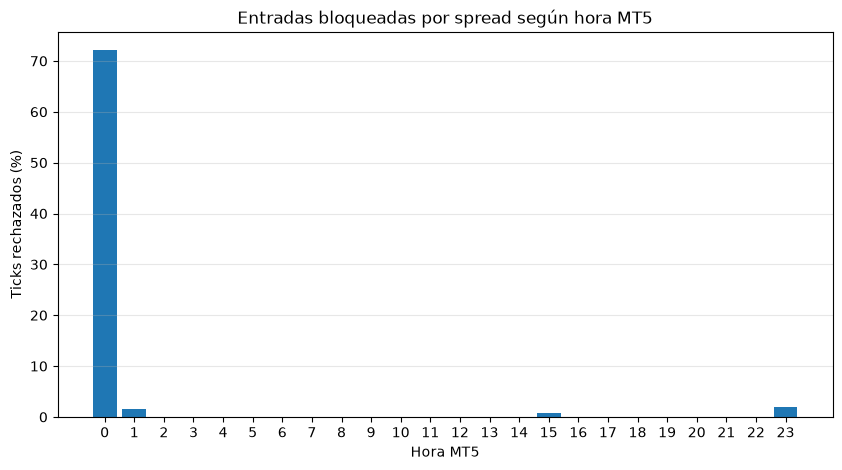

In [22]:
plt.figure(
    figsize=(10, 5)
)


plt.bar(
    execution_by_hour.index,
    execution_by_hour[
        "rejected_pct"
    ]
)


plt.title(
    "Entradas bloqueadas por spread según hora MT5"
)

plt.xlabel(
    "Hora MT5"
)

plt.ylabel(
    "Ticks rechazados (%)"
)

plt.xticks(
    range(24)
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## 23. Resumen automático del modelo

Mostramos las principales reglas y resultados de nuestro modelo básico
de ejecución.

In [23]:
phase4_summary = pd.DataFrame(
    [
        {
            "concepto":
                "Ticks disponibles",
            "valor":
                len(ticks_exec)
        },

        {
            "concepto":
                "Precio entrada BUY",
            "valor":
                "Ask"
        },

        {
            "concepto":
                "Precio salida BUY",
            "valor":
                "Bid"
        },

        {
            "concepto":
                "Precio entrada SELL",
            "valor":
                "Bid"
        },

        {
            "concepto":
                "Precio salida SELL",
            "valor":
                "Ask"
        },

        {
            "concepto":
                "P99 spread",
            "valor":
                spread_p99
        },

        {
            "concepto":
                "Límite provisional entrada",
            "valor":
                MAX_ENTRY_SPREAD_POINTS
        },

        {
            "concepto":
                "% ticks aceptables",
            "valor":
                pct_spread_ok
        },

        {
            "concepto":
                "% ticks rechazados",
            "valor":
                pct_spread_rejected
        },

        {
            "concepto":
                "Slippage",
            "valor":
                "NO incluido"
        },

        {
            "concepto":
                "Latencia",
            "valor":
                "NO incluida"
        }
    ]
)


display(
    phase4_summary
)

,concepto,valor
0,Ticks disponibles,1064157
1,Precio entrada BUY,Ask
2,Precio salida BUY,Bid
3,Precio entrada SELL,Bid
4,Precio salida SELL,Ask
5,P99 spread,2.0
6,Límite provisional entrada,2.0
7,% ticks aceptables,99.575157
8,% ticks rechazados,0.424843
9,Slippage,NO incluido


# Conclusión de la Fase 4

En esta fase hemos construido la primera versión del modelo de ejecución.

Ya no suponemos que una operación puede abrirse y cerrarse utilizando
un único precio.

Ahora respetamos la microestructura Bid/Ask:

BUY:
- Entrada = Ask
- Salida = Bid

SELL:
- Entrada = Bid
- Salida = Ask

También hemos demostrado que una operación abierta y cerrada sin
movimiento del mercado comienza con una pérdida equivalente al spread.

Además, utilizamos provisionalmente el percentil 99 del spread como
referencia para impedir nuevas entradas cuando el coste de ejecución
es anormalmente elevado.

Este límite todavía no constituye una regla definitiva de trading.

El modelo actual supone:

- Slippage = 0.
- Latencia = 0.
- Comisión = 0.
- Swap = 0.

La siguiente fase será:

`05_slippage_model.ipynb`